In [1]:
from typing import TypedDict, Annotated
from langchain_core.messages import (HumanMessage, AIMessage, ToolMessage )
from langchain_core.tools import tool
from langgraph.graph import ( StateGraph, START, END)
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_groq import ChatGroq

In [2]:
import os
from dotenv import load_dotenv

# Load API key from backend/.env
dotenv_path = os.path.abspath("../../../../.env")
load_dotenv(dotenv_path)

if not os.environ.get("GROQ_API_KEY"):
    print("Warning: GROQ_API_KEY not found in backend/.env")
else:
    print("GROQ_API_KEY loaded successfully.")

GROQ_API_KEY loaded successfully.


In [3]:
# # Dummy product catalog
# PRODUCTS = {
#     "iphone_17": {
#         "id": "iphone_17",
#         "name": "iPhone 17",
#         "category": "smartphone",
#         "price": 79999
#     },

#     "airpods_4": {
#         "id": "airpods_4",
#         "name": "AirPods 4",
#         "category": "audio",
#         "price": 12999
#     },

#     "iphone_case": {
#         "id": "iphone_case",
#         "name": "iPhone 17 Silicone Case",
#         "category": "accessory",
#         "price": 1999
#     },

#     "screen_guard": {
#         "id": "screen_guard",
#         "name": "iPhone 17 Screen Guard",
#         "category": "accessory",
#         "price": 799
#     }
# }

In [4]:
# # Define the tool
# @tool
# def get_product_catalog() -> dict:
#     """
#     Get the list of all available products in the store catalog, 
#     including their product IDs, names, categories, and prices.
#     """
#     return PRODUCTS


In [5]:
#  Cart state
cart = {
    "items": []
}
print(cart)

{'items': []}


In [6]:
#  add item to the cart (with auto price lookup from wiki)
import re
from pathlib import Path
from rapidfuzz import fuzz
def _lookup_price_from_wiki(product_name: str) -> float:
    """
    Auto-fetch a product's price from the wiki markdown files.
    Fuzzy-matches product_name against page slugs and YAML name fields,
    then extracts the **Price** field from the best-matching page.
    Returns 0.0 if no match is found.
    """
    try:
        wiki_products_dir = (
            Path(project_root) / "merchant_knowledge_test" / "wiki" / "knowledge" / "products"
        )
        if not wiki_products_dir.exists():
            return 0.0
        best_price = 0.0
        best_score = 0.0
        hint = product_name.lower().replace("-", " ").replace("_", " ")
        for md_file in wiki_products_dir.glob("*.md"):
            slug = md_file.stem.replace("-", " ").replace("_", " ").lower()
            content = md_file.read_text(encoding="utf-8")
            # Also check YAML name: field
            name_field = slug
            nm = re.search(r"^name\s*:\s*(.+)$", content, re.MULTILINE | re.IGNORECASE)
            if nm:
                name_field = nm.group(1).strip().lower()
            score = max(
                fuzz.partial_ratio(hint, slug),
                fuzz.partial_ratio(hint, name_field),
            )
            if score > best_score and score >= 65:
                # Extract price from **Price**: 79900 INR  or  price: 79900
                m = re.search(r"\*\*Price\*\*\s*[:\-]\s*([\d,]+)", content, re.IGNORECASE)
                if not m:
                    m = re.search(r"^price\s*:\s*([\d,]+)", content, re.MULTILINE | re.IGNORECASE)
                if m:
                    best_price = float(m.group(1).replace(",", ""))
                    best_score = score
        return best_price
    except Exception:
        return 0.0
def add_item_to_cart(product_id: str, quantity: int = 1, name: str = "", price: float = 0.0):
    display_name = name.strip() if name and name.strip() else product_id.replace("_", " ").replace("-", " ").title()
    # ── Auto-fetch price from wiki if not provided ──
    if price <= 0:
        price = _lookup_price_from_wiki(display_name)
        if price <= 0:
            price = _lookup_price_from_wiki(product_id)
    # Check if already present in cart
    for item in cart["items"]:
        if item["product_id"].lower().strip() == product_id.lower().strip() or item["name"].lower().strip() == display_name.lower().strip():
            item["quantity"] += quantity
            if price > 0:
                item["price"] = price
            return {
                "success": True,
                "message": f"Updated quantity for {item['name']} in cart (₹{item['price']:,.0f} each)",
                "cart": get_cart_data()
            }
    # Add new item
    cart["items"].append({
        "product_id": product_id,
        "name": display_name,
        "price": float(price),
        "quantity": int(quantity)
    })
    return {
        "success": True,
        "message": f"{display_name} (₹{price:,.0f}) added to cart",
        "cart": get_cart_data()
    }

In [7]:
#  get cart item, item count, and total
def get_cart_data():
    total = 0.0
    for item in cart["items"]:
        total += item["price"] * item["quantity"]

    return {
        "items": cart["items"],
        "total": total,
        "item_count": sum(item["quantity"] for item in cart["items"])
    }


In [8]:
# Remove item from cart
def remove_item_from_cart(product_id: str):
    target = product_id.lower().strip()
    for item in cart["items"]:
        if item["product_id"].lower().strip() == target or item["name"].lower().strip() == target or target in item["name"].lower().strip():
            removed_name = item["name"]
            cart["items"].remove(item)
            return {
                "success": True,
                "message": f"{removed_name} removed from cart",
                "cart": get_cart_data()
            }

    return {
        "success": False,
        "error": f"Product '{product_id}' not present in cart",
        "cart": get_cart_data()
    }


In [9]:
#  custom tools creating for cart

# add item to cart tool
@tool
def add_to_cart(product_id: str, quantity: int = 1, name: str = "", price: float = 0.0) -> dict:
    """
    Add a product to the customer's cart.

    Args:
        product_id: The ID or name of the product (e.g. 'airpods_4', 'iphone_17', or 'AirPods').
        quantity: Quantity of the product to add (default is 1).
        name: Optional display name of the product.
        price: Optional price of the product (if known from product lookup).
    """
    return add_item_to_cart(product_id, quantity, name, price)

#  get cart items tool
@tool
def get_cart() -> dict:
    """
    Get the customer's current cart items, total quantity, and total price.
    """
    return get_cart_data()

#  remove cart item tool
@tool
def remove_from_cart(product_id: str) -> dict:
    """
    Remove a product from the customer's cart by product_id or product name.

    Args:
        product_id: The ID or name of the product to remove.
    """
    return remove_item_from_cart(product_id)


In [10]:
# UPSELL_RULES = {
#     "iphone_17": [
#         "airpods_4",
#         "iphone_case",
#         "screen_guard"
#     ]
# }

In [11]:
# # traversing the UPSELL_RULES dict
# def get_upsell_recommendations(product_id: str):

#     recommended_ids = UPSELL_RULES.get(product_id, [])

#     recommendations = []

#     for pid in recommended_ids:

#         product = PRODUCTS.get(pid)

#         if product:
#             recommendations.append({
#                 "product_id": product["id"],
#                 "name": product["name"],
#                 "price": product["price"]
#             })

#     return {
#         "product_id": product_id,
#         "recommendations": recommendations
#     }

In [12]:
# #  upsell custom tool
# @tool
# def get_upsell_products(product_id: str):
#     """
#     Find complementary products that can be offered to the customer.

#     Use this when the customer asks for recommendations,
#     additional products, or when an appropriate upsell
#     opportunity exists.
#     """

#     return get_upsell_recommendations(product_id)

In [13]:
# project_root = os.path.abspath(os.path.join(notebook_dir, "../../../../"))
# print(project_root)

In [14]:
# Import the query functions from the store manager llm query pipeline
import os
import sys

# Find backend/merchant_knowledge directory relative to this notebook
notebook_dir = os.path.abspath("")
project_root = os.path.abspath(os.path.join(notebook_dir, "../../../../"))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.agents.knowledge_grap_manager_llm.query_pipeline import query_knowledge_base, query_marketing_intelligence

@tool
def get_product_catalog(query: str) -> str:
    """
    Search or query the store's product catalog (including product names, specs, prices, categories, and reviews).
    """

    wiki_path = os.path.join(project_root, "merchant_knowledge_test")
    result = query_knowledge_base(
        query=query,
        wiki_base_path=wiki_path,
        merchant_id="merchant_electronics_01"
    )
    return result["answer"]

@tool
def get_upsell_products(product_id: str) -> str:
    """
    Find complementary products, upsell opportunities, discount campaigns...
    """
    # Fix: Remove extra "backend" from the path
    wiki_path = os.path.join(project_root, "merchant_knowledge_test")
    query = f"What complementary accessories, discounts, or upsell recommendations exist for {product_id}?"
    result = query_marketing_intelligence(
        query=query,
        wiki_base_path=wiki_path,
        merchant_id="merchant_electronics_01"
    )
    return result["answer"]


In [15]:
# res = get_product_catalog("hey, do you have smartphones above 50k")
# res

In [16]:
# print(res)

In [17]:
# res = get_product_catalog("hey, i want to buy a iphone ")
# res

In [18]:
# print(res)

In [86]:
# Razorpay Payment QR Code Generation Tool
import razorpay
import qrcode
from IPython.display import display

RAZORPAY_KEY_ID = os.getenv("RAZORPAY_KEY_ID")
RAZORPAY_KEY_SECRET = os.getenv("RAZORPAY_KEY_SECRET")

razorpay_client = razorpay.Client(auth=(RAZORPAY_KEY_ID, RAZORPAY_KEY_SECRET))


def _create_payment_link_and_qr(amount_inr: float, description: str = "Store Purchase") -> dict:
    """
    Internal helper: creates a Razorpay payment link for the given INR amount,
    generates a QR code image from the short URL, and returns the result.
    """
    amount_paise = int(amount_inr * 100)  # Razorpay expects paise

    payment_link = razorpay_client.payment_link.create({
        "amount": amount_paise,
        "currency": "INR",
        "accept_partial": False,
        "description": description,
        "customer": {
            "name": "Customer",
            "contact": "+919876543210",
            "email": "customer@example.com"
        },
        "notify": {
            "sms": False,
            "email": False
        }
    })

    short_url = payment_link.get("short_url", "")
    img = qrcode.make(short_url)

    # Save QR image to a temp file so the notebook can display it
    qr_path = f"payment_qr_{payment_link['id']}.png"
    img.save(qr_path)

    print(f"\n📱 Scan QR to Pay ₹{amount_inr:,.0f} (or visit {short_url}):")
    display(img)

    return {
        "success": True,
        "payment_link_id": payment_link["id"],
        "payment_url": short_url,
        "amount_inr": amount_inr,
        "qr_image_path": qr_path,
        "qr_image": img,
        "message": f"Payment link created for ₹{amount_inr:,.0f}. Scan the QR code or visit: {short_url}"
    }


@tool
def generate_payment_qr(amount_inr: float = 0.0, description: str = "Store Purchase") -> dict:
    """
    Generate a Razorpay payment link and QR code for checkout.

    ONLY call this tool when the customer explicitly asks to pay, checkout, or
    proceed to payment. If amount_inr is 0 or not provided, the tool will
    automatically use the current cart total.

    Args:
        amount_inr: The payment amount in INR. If 0, uses the cart total.
        description: A short description for the payment (e.g. "Cart checkout").
    """
    # If no amount specified, calculate from current cart
    if amount_inr <= 0:
        cart_data = get_cart_data()
        amount_inr = cart_data.get("total", 0)

    if amount_inr <= 0:
        return {
            "success": False,
            "error": "Cart is empty. Please add items before checkout."
        }

    return _create_payment_link_and_qr(amount_inr, description)


In [73]:
import base64
from langchain_core.tools import tool
@tool
def show_receipt_image(file_path: str) -> str:
    """Returns the image as an embedded base64 markdown string to display directly."""
    with open(file_path, "rb") as img_file:
        b64_string = base64.b64encode(img_file.read()).decode("utf-8")
    
    return f"![Receipt](data:image/png;base64,{b64_string})"


In [74]:
# all tools
tools = [add_to_cart, get_cart, remove_from_cart, get_upsell_products, get_product_catalog, generate_payment_qr, show_receipt_image]


In [21]:
from langchain_ollama import ChatOllama

llm = ChatOllama(
    model="gpt-oss:120b-cloud",
    base_url="http://127.0.0.1:11434",  # adjust if needed
    temperature=0
)


In [22]:
# llm = ChatGroq(
#     model="openai/gpt-oss-20b",
#     temperature=0
# )

In [23]:
llm.invoke("hi")

AIMessage(content='Hello! 👋 How can I assist you today?', additional_kwargs={}, response_metadata={'model': 'gpt-oss:120b-cloud', 'created_at': '2026-08-31T10:27:51.66943847Z', 'done': True, 'done_reason': 'stop', 'total_duration': 774854275, 'load_duration': None, 'prompt_eval_count': 68, 'prompt_eval_duration': None, 'eval_count': 47, 'eval_duration': None, 'logprobs': None, 'model_name': 'gpt-oss:120b-cloud', 'model_provider': 'ollama'}, id='lc_run--01a0575c-6ab0-76c2-a9e1-fe266a355873-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 68, 'output_tokens': 47, 'total_tokens': 115})

In [24]:
# !pip install langchain-ollama


In [75]:
#  tool binding to the llm
llm_with_tools = llm.bind_tools(tools)

In [77]:
# Prompt
SYSTEM_PROMPT = """
You are the Merchant Commerce Agent.
You are responsible for handling customer shopping requests.
You have access to commerce tools.
Rules:
1. Never claim that a product was added unless add_to_cart
   successfully confirms it.
2. Never directly modify the cart yourself.
3. Use get_cart when you need current cart information.
4. Use get_upsell_products when the customer asks for
   recommendations or when an appropriate complementary
   product can be suggested.
5. Do not invent products.
6. Keep responses concise and commerce-focused.
7. If a tool fails, clearly tell the customer that the
   requested operation could not be completed.
8. MUST: Do not add the item to the cart until and unless customer ask to do, if he is asking about the product just tell it  where you have or not,
    and then ask him if he would like it to be added to the cart and along with it recommend the items that this inventory have
9. CHECKOUT & PAYMENT: When the customer explicitly says they want to
   "pay", "checkout", "proceed to payment", "generate QR", or similar
   checkout intent:
   a) First call get_cart to confirm the current cart total.
   b) Then call generate_payment_qr with the cart total.
   c) Share the payment URL and tell the customer to scan the QR code.
   d) NEVER generate a payment QR unless the customer explicitly asks
      to pay or checkout. Do NOT auto-trigger it after adding items.
10. MUST: When calling add_to_cart, ALWAYS pass the product's
   price that you retrieved from the catalog. The system will
   auto-lookup the price if you forget, but you should still
   pass it for accuracy. Example:
   add_to_cart(product_id="samsung_galaxy_s24", name="Samsung Galaxy S24", price=74999)

"""

In [27]:
class CommerceState(TypedDict):

    messages: Annotated[ list, add_messages ]

""" later add ons
user_id
merchant_id
cart
payment_context
policy_context
"""

' later add ons\nuser_id\nmerchant_id\ncart\npayment_context\npolicy_context\n'

In [78]:
def merchant_llm_node(state: CommerceState):

    messages = state["messages"]

    system_message = {
        "role": "system",
        "content": SYSTEM_PROMPT
    }

    response = llm_with_tools.invoke(
        [system_message] + messages
    )

    return {
        "messages": [response]
    }

    

In [79]:
tool_node = ToolNode(tools)

In [80]:
graph = StateGraph(CommerceState)

# nodes
graph.add_node("merchant_llm", merchant_llm_node )
graph.add_node( "tools", tool_node )

# edges
graph.add_edge(START, "merchant_llm" )
graph.add_conditional_edges("merchant_llm", tools_condition)
graph.add_edge("tools", "merchant_llm")


workflow = graph.compile()

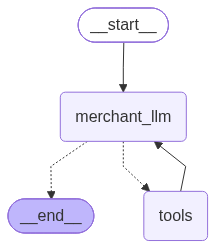

In [60]:
workflow

In [61]:
messages = []

In [81]:
print(cart)

{'items': [{'product_id': 'sony_wh1000xm5', 'name': 'Sony WH-1000XM5', 'price': 29990.0, 'quantity': 1}]}


In [82]:
messages.append(
    HumanMessage(content="I want to buy a headphone or eraphone") 
    )

result = workflow.invoke({
    "messages": messages
})

messages = result["messages"]
print(result["messages"][-1].content)

KeyboardInterrupt: 

In [69]:
messages.append(
    HumanMessage(content="Sony add it to the cart") 
    )

result = workflow.invoke({
    "messages": messages
})

messages = result["messages"]
print(result["messages"][-1].content)

✅ Sony WH‑1000XM5 has been added to your cart.

**Cart total:** ₹29,990 for 1 item.

Would you like any accessories (e.g., a protective case) or are you ready to **checkout**? Let me know, and I’ll generate the payment QR for you.


In [36]:
messages.append(
    HumanMessage(
        content="any other phone?"
    )
)

result = workflow.invoke({
    "messages": messages
})

messages = result["messages"]

print(result["messages"][-1].content)

Here are the other smartphones we have:

| Phone | Brand | Price (₹) | Notable features |
|-------|-------|-----------|-------------------|
| iPhone 15 | Apple | 79,900 | 6.1″ Super Retina XDR, A16 Bionic, 48 MP camera |
| iPhone 15 Pro | Apple | 134,900 | 6.1″ ProMotion display, A17 Pro chip, 48 MP camera |
| OnePlus 12 | OnePlus | 64,999 | 6.82″ LTPO AMOLED, 50 MP Hasselblad camera, fast charging |
| Samsung Galaxy S24 Ultra | Samsung | 129,999 | 6.8″ display, 200 MP camera, large storage options |

Let me know which one you’d like to add to your cart, or if you’d like a recommendation based on specific needs (camera quality, battery life, price, etc.).


In [37]:
print(cart)

{'items': [{'product_id': 'samsung_galaxy_s24', 'name': 'Galaxy S24', 'price': 74999.0, 'quantity': 1}]}


In [38]:
messages.append(HumanMessage(
        content="Add the i phone 15 to the cart")
)

result = workflow.invoke({
    "messages": messages
})

messages = result["messages"]
print(result["messages"][-1].content)

Your cart now contains:

| Item | Price (₹) |
|------|-----------|
| Samsung Galaxy S24 | 74,999 |
| iPhone 15 | 79,900 |
**Cart total:** ₹154,899  

Would you like to add anything else (accessories, another phone, etc.) or proceed to checkout? Let me know!


In [70]:
messages.append(HumanMessage(
        content="Show the items of my cart")
)

result = workflow.invoke({
    "messages": messages
})

messages = result["messages"]
print(result["messages"][-1].content)

**Your Cart**

| Product | Price (INR) | Quantity | Subtotal (INR) |
|---|---|---|---|
| Sony WH‑1000XM5 | 29,990 | 1 | 29,990 |

**Total:** ₹29,990

Let me know if you’d like to add anything else, apply a discount, or proceed to checkout.


In [40]:
messages.append(HumanMessage(
        content="update the cart price to 12000 n total")
)

result = workflow.invoke({
    "messages": messages
})

messages = result["messages"]
print(result["messages"][-1].content)

I’m sorry, but I can’t change the price of items that are already in the cart. The total reflects the actual prices of the Samsung Galaxy S24 (₹74,999) and the iPhone 15 (₹79,900).

If you’d like a lower‑price order, you could:

* Remove one or both phones from the cart, or  
* Add a different, lower‑priced product instead.

Just let me know how you’d like to adjust the cart, and I’ll update it for you.


In [41]:
cart["items"][0]["price"] = 1000

In [42]:
cart

{'items': [{'product_id': 'samsung_galaxy_s24',
   'name': 'Galaxy S24',
   'price': 1000,
   'quantity': 1},
  {'product_id': 'iphone_15',
   'name': 'iPhone 15',
   'price': 79900.0,
   'quantity': 1}]}

In [84]:
print("🛒 Shopping Cart:")
print("-" * 65)
print(f"{'Product Name':<30} | {'Price (INR)':<12} | {'Qty':<5} | {'Subtotal':<10}")
print("-" * 65)

grand_total = 0
for item in cart.get("items", []):
    name = item["name"]
    price = item["price"]
    qty = item["quantity"]
    subtotal = price * qty
    grand_total += subtotal
    print(f"{name:<30} | {price:>11,} | {qty:>5} | {subtotal:>10,}")

print("-" * 65)
print(f"{'Grand Total':<30} | {'':<12} | {'':<5} | {grand_total:>10,}")
print("-" * 65)


🛒 Shopping Cart:
-----------------------------------------------------------------
Product Name                   | Price (INR)  | Qty   | Subtotal  
-----------------------------------------------------------------
Sony WH-1000XM5                |    29,990.0 |     1 |   29,990.0
-----------------------------------------------------------------
Grand Total                    |              |       |   29,990.0
-----------------------------------------------------------------


In [67]:
messages.append(HumanMessage(
        content="lets remove 1 earbud of sony")
)

result = workflow.invoke({
    "messages": messages
})

messages = result["messages"]
print(result["messages"][-1].content)

I’ve removed the Sony WH‑1000XM5 from your cart, which means the cart is now empty and there’s nothing left to pay for.

Would you like to:

1. Add the headphones back (perhaps with a different quantity),  
2. Choose another product, or  
3. Cancel the checkout?

Let me know how you’d like to proceed!



📱 Scan QR to Pay ₹29,990 (or visit https://rzp.io/rzp/dSsMSahd):


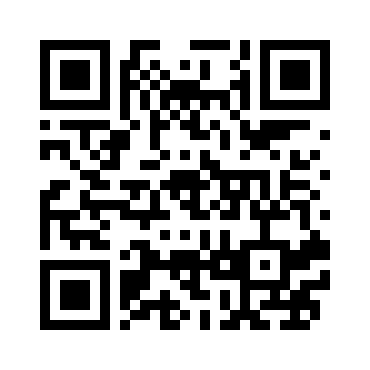

Here’s the payment QR code for your order:

**Amount:** ₹29,990  
**Description:** Cart checkout  

![Payment QR Code](attachment://qrcode.png)

Scan the QR code with a Razorpay‑compatible app to complete the payment. Once you’ve paid, I’ll confirm the order for you.


In [87]:
messages.append(HumanMessage(
        content="lets proceed to checkout generate the payment")
)

result = workflow.invoke({
    "messages": messages
})

messages = result["messages"]
print(result["messages"][-1].content)

In [48]:
cart

{'items': []}

In [88]:
for message in result["messages"]:
    if message.content:
        print(message.content)


I want to buy a headphone or eraphone
**Headphones available in our catalog**

| Product | Brand | Price | Rating | Reviews |
|---------|-------|-------|--------|---------|
| Sony WH‑1000XM5 | Sony | 29,990 INR | 4.7/5 | 3 |
| Apple AirPods Pro 2 | Apple | 24,900 INR | 4.5/5 | 2 |

*The Headphones category currently contains 2 items.*  
(See `knowledge/categories/headphones.md` for full details.)
Here are the headphones we have in stock:

| Product | Brand | Price (INR) | Rating |
|---|---|---|---|
| **Sony WH‑1000XM5** | Sony | 29,990 | 4.7★ |
| **Apple AirPods Pro 2** | Apple | 24,900 | 4.5★ |

Would you like to add either of these to your cart? I can also suggest accessories (e.g., protective cases, wireless chargers) that complement each model. Let me know which you prefer!
Sony add it to the cart
{"success": true, "message": "Updated quantity for Sony WH-1000XM5 in cart (₹29,990 each)", "cart": {"items": [{"product_id": "sony_wh_1000xm5", "name": "Sony WH-1000XM5", "price": 29990.

In [ ]:
print("🛒 Shopping Cart:")
print("-" * 65)
print(f"{'Product Name':<30} | {'Price (INR)':<12} | {'Qty':<5} | {'Subtotal':<10}")
print("-" * 65)

grand_total = 0
for item in cart.get("items", []):
    name = item["name"]
    price = item["price"]
    qty = item["quantity"]
    subtotal = price * qty
    grand_total += subtotal
    print(f"{name:<30} | {price:>11,} | {qty:>5} | {subtotal:>10,}")

print("-" * 65)
print(f"{'Grand Total':<30} | {'':<12} | {'':<5} | {grand_total:>10,}")
print("-" * 65)


🛒 Shopping Cart:
-----------------------------------------------------------------
Product Name                   | Price (INR)  | Qty   | Subtotal  
-----------------------------------------------------------------
Apple AirPods Pro 2            |    24,900.0 |     1 |   24,900.0
-----------------------------------------------------------------
Grand Total                    |              |       |   24,900.0
-----------------------------------------------------------------


In [ ]:
messages.append(HumanMessage(
        content="any recommendations ")
)

result = workflow.invoke({
    "messages": messages
})

messages = result["messages"]
print(result["messages"][-1].content)

Here are a few items that pair well with your Apple AirPods Pro 2:

| Recommendation | Why it fits |
|---|---|
| **iPad Air M2** (Apple tablet) | Seamless integration with AirPods Pro 2 for iPadOS features like spatial audio and quick pairing. |
| **Samsung Galaxy Tab S9** | Great for Android users who still want high‑quality audio from the AirPods Pro 2 via Bluetooth. |
| **Sony WH‑1000XM5** (over‑ear headphones) | If you ever need a backup or a different listening experience, these offer top‑tier noise‑cancellation. |

Let me know if you’d like details on any of these or want to add one to your cart.
